# Instructor solution · Lab 02 · Inspect the machine

**Time:** 2 hours; 60–90 minutes coding. **Preparation:**
[Lecture 02](../notebooks/02_floating_point.ipynb).

Investigate representation and rounding with exact references. Complete exercise
cells, then run the diagnostic cells. Submit code, plots, and written explanations.

**Instructor copy.** Contains solutions and marking guidance. Do not distribute with the student lab.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'solutions'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
import math
import sys
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from vc.environment import require_binary64

require_binary64()
print("Significand bits:", sys.float_info.mant_dig)

Significand bits: 53


## Task A · Predict neighboring gaps (30 minutes)

Implement `neighbor_gaps(x)` for finite positive floats whose neighbors are also
finite. Return the exact rational gaps below and above `x`. Convert neighbors
to fractions **before** subtraction. Explain why these gaps differ at 1 and 2.

In [3]:
def neighbor_gaps(x):
    exact = Fraction.from_float(x)
    lower = Fraction.from_float(math.nextafter(x, -math.inf))
    upper = Fraction.from_float(math.nextafter(x, math.inf))
    return exact - lower, upper - exact

In [4]:
assert neighbor_gaps(1.0) == (Fraction(1, 2**53), Fraction(1, 2**52))
assert neighbor_gaps(1.5) == (Fraction(1, 2**52), Fraction(1, 2**52))
assert neighbor_gaps(2.0) == (Fraction(1, 2**52), Fraction(1, 2**51))
assert neighbor_gaps(math.nextafter(0.0, math.inf)) == (Fraction(1, 2**1074),)*2
for x in [0.5, 1.0, 1.5, 2.0]:
    print(x, neighbor_gaps(x))

0.5 (Fraction(1, 18014398509481984), Fraction(1, 9007199254740992))
1.0 (Fraction(1, 9007199254740992), Fraction(1, 4503599627370496))
1.5 (Fraction(1, 4503599627370496), Fraction(1, 4503599627370496))
2.0 (Fraction(1, 4503599627370496), Fraction(1, 2251799813685248))


**Answer.** A normal significand has 52 stored fractional bits, so the
upward gap at 2ᵉ is 2ᵉ⁻⁵². Except at the normal/subnormal transition, the
neighbor below a power of two belongs to the preceding binade and has half that
gap. Subnormal spacing is fixed at 2⁻¹⁰⁷⁴; it does not keep halving toward zero.

## Task B · Lost increments (20 minutes)

Find the smallest nonnegative integer `n` for which `(2.0**n + 1) == 2.0**n`.
Use a bounded search and explain why the result follows from ties-to-even.
Also evaluate `(2.0**n - 1) == 2.0**n` at that same exponent.

In [5]:
def first_lost_increment():
    for n in range(61):
        if 2.0**n + 1 == 2.0**n:
            return n
    raise RuntimeError("No threshold found within the promised search range")

In [6]:
n = first_lost_increment()
assert isinstance(n, int) and 0 < n <= 60
assert 2.0**n + 1 == 2.0**n
assert all(2.0**k + 1 != 2.0**k for k in range(n))
print("First exponent:", n)
print("Subtraction also lost?", 2.0**n - 1 == 2.0**n)

First exponent: 53
Subtraction also lost? False


**Answer.** The exponent is 53. The upward spacing is 2, so adding 1
lands at a midpoint and nearest-even selects 2⁵³. The downward spacing is 1, so
subtracting 1 is exact. Machine epsilon is 2⁻⁵², the gap above 1; unit roundoff
is 2⁻⁵³, the normal-range relative rounding-error bound. The value 1 is exactly
representable, so its input conversion did not cause the lost increment.

## Task C · Audit decimal input (15 minutes)

First predict which expression in each pair preserves a previously rounded
float. Then run the cell and compare their exact rational values.

In [7]:
with localcontext() as context:
    context.prec = 60
    print("Decimal from string:", Decimal("0.3"))
    print("Decimal from float: ", Decimal(0.3))
print("Fraction from string:", Fraction("0.3"))
print("Fraction from float: ", Fraction.from_float(0.3))

Decimal from string: 0.3
Decimal from float:  0.299999999999999988897769753748434595763683319091796875
Fraction from string: 3/10
Fraction from float:  5404319552844595/18014398509481984


**Answer.** Increasing the precision cannot recover the intended decimal
from a float already constructed. The string constructor expresses exact 3/10;
the float constructor expresses the exact stored dyadic number. For a measurement
known only to belong to [0.29,0.31], preserve that entire set with endpoints enclosed
outward. Choosing its midpoint and adding digits would discard the uncertainty.

## Task D · Bound a time-conversion error (35 minutes)

This is a simplified model inspired by the Patriot example, not its full software.
A counter records exact tenths of seconds. The conversion constant $1/10$ is
truncated downward to `bits` binary fractional places.

Implement `time_conversion_error(hours, bits)` for nonnegative **integer** hours
and positive integer `bits`. Return the exact nonnegative error in seconds.
Use integer arithmetic to construct the truncated constant; avoid converting
`0.1` into a fraction. Compare 16, 23, and 32 fractional bits over 0–100 hours.

In [8]:
def time_conversion_error(hours, bits):
    if not isinstance(hours, int) or hours < 0:
        raise ValueError("hours must be a nonnegative integer")
    if not isinstance(bits, int) or bits <= 0:
        raise ValueError("bits must be a positive integer")
    scale = 2**bits
    truncated = Fraction(scale // 10, scale)
    return hours * 3600 * 10 * (Fraction(1, 10) - truncated)

In [9]:
assert time_conversion_error(0, 23) == 0
assert isinstance(time_conversion_error(1, 23), Fraction)
assert time_conversion_error(100, 23) == 100 * time_conversion_error(1, 23)
for bits in [16, 23, 32]:
    assert 0 <= time_conversion_error(100, bits) < Fraction(100*3600*10, 2**bits)
print("100-hour error, 23 bits:", time_conversion_error(100, 23))

100-hour error, 23 bits: 5625/16384


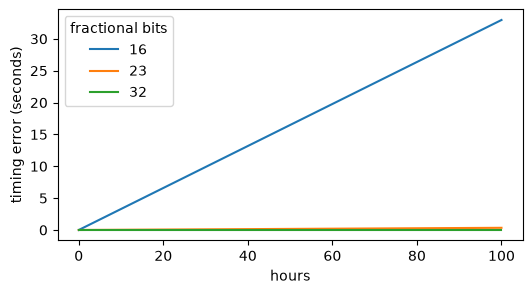

In [10]:
hours_grid = list(range(101))
fig, ax = plt.subplots(figsize=(6, 3))
for bits in [16, 23, 32]:
    ax.plot(hours_grid, [float(time_conversion_error(h, bits)) for h in hours_grid], label=str(bits))
ax.set(xlabel="hours", ylabel="timing error (seconds)")
ax.legend(title="fractional bits")
display(fig)
plt.close(fig)

**Answer.** If q = floor(2ᵇ/10)/2ᵇ, then 0 ≤ 1/10 − q < 2⁻ᵇ.
For N ticks, 0 ≤ error < N·2⁻ᵇ. This follows from the floor inequality and
multiplication by a nonnegative integer, not from a sampled graph.
At 23 fractional bits the exact error per hour is 225/65536 seconds. The largest
integer h satisfying h·225/65536 ≤ 1/100 is 2; three hours exceeds the bound.
These statements assume exact tick counts and precisely the specified conversion.
They are properties of a teaching model, not operational advice for a historical system.

**Homework answer.** The relative error for rounding 2⁻¹⁰⁷⁵ to zero is 1.
Its absolute error is 2⁻¹⁰⁷⁵, half the subnormal spacing. The exact value is outside
the normal range, so the normal relative bound does not apply.

## Homework and an inconclusive case

**Homework (20 minutes):** the exact number $2^{-1075}$ rounds to zero in
binary64 under nearest-even. Compute its relative error and explain why the
normal-range $u$ bound does not apply. State an absolute bound instead.

**Optional:** write a binary64 decoder using `struct`, and reconstruct normal
values as exact fractions. Extend it to subnormals, distinguishing finite values
from infinities and NaNs rather than treating all exponent fields alike.

**Conclusion:** could a plot of time-conversion error alone certify a bound at
every duration? Identify the mathematical formula that makes the bound rigorous.